# 52 Random Forest

Entrena modelos de Random Forest para `sale` y `rent` prediciendo `log_precio`.

**Pipeline:**
1. Eliminación de outliers en el target (`log_precio`) con método IQR antes del split
2. Preprocesado: imputación de medianas (numéricas) + OneHotEncoder (categóricas)
3. Búsqueda de hiperparámetros con `RandomizedSearchCV` + validación cruzada (CV=5)
4. Evaluación con métricas train / CV / test y análisis de sobreajuste
5. Gráficos diagnósticos: Real vs Predicho, histograma de residuos y Q-Q plot

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 220)

# ── Configuración global ──────────────────────────────────────────────────────
RANDOM_STATE  = 42
TEST_SIZE     = 0.20
N_SPLITS      = 5
N_ITER_SEARCH = 50      # Aumentado a 50 para explorar más combinaciones
TARGET_COL    = "log_precio"
IQR_FACTOR    = 1.5     # Factor IQR para detectar outliers (estándar = 1.5; 2.0 más permisivo)

# ── Columnas excluidas siempre ────────────────────────────────────────────────
EXCLUDE_COLS = {
    "codigo_inmueble",
    "precio",
    "precio_m2",
    "precio_m2_municipio_media",
    "planta",
    "inv_distancia_min_playa_km",
    "inv_distancia_min_supermercado_km",
    "inv_distancia_min_colegio_km",
    "superficie_construida_m2_2",
    "numero_banos_2",
    "numero_dormitorios_2",
    "habitaciones_2",
}

# ── Features base ─────────────────────────────────────────────────────────────
BASE_FEATURES = [
    "superficie_construida_m2",
    "numero_dormitorios",
    "numero_banos",
    "tipologia_unificada_piso",
    "tipologia_unificada_unifamiliar",
    "distancia_min_playa_km",
    "distancia_min_colegio_km",
    "distancia_centro_municipio_km",
    "score_cercania_servicios",
    "tiene_garaje",
    "obra_nueva"
    ]

# ── Espacio de búsqueda de hiperparámetros ────────────────────────────────────
# Tras eliminar outliers los datos son más limpios, por lo que ampliamos ligeramente
# el rango de profundidad y reducimos el suelo de min_samples_leaf
PARAM_DIST = {
    "rf__n_estimators":      [200, 300, 500],        # Más árboles → estimaciones más estables
    "rf__max_depth":         [6, 8, 10, 12, 15],     # Ahora incluimos 15 (datos más limpios)
    "rf__min_samples_split": [15, 20, 30, 50],       # Mínimo de muestras para dividir un nodo
    "rf__min_samples_leaf":  [5, 10, 15, 20],        # Bajamos el mínimo a 5 (outliers ya eliminados)
    "rf__max_features":      [0.3, 0.4, 0.5, 0.6],  # Fracción de features por árbol
    "rf__max_samples":       [0.7, 0.8, 0.9],        # Fracción de filas por árbol (bagging)
}

# ── Rutas de los datasets ─────────────────────────────────────────────────────
def find_project_root(start_path: Path) -> Path:
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "data" / "gold").exists():
            return candidate
    raise FileNotFoundError("No se encontro la raiz del proyecto con data/gold")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATASETS = {
    "sale": PROJECT_ROOT / "data" / "gold" / "final_sale.csv",
    "rent": PROJECT_ROOT / "data" / "gold" / "final_rent.csv",
}

for name, path in DATASETS.items():
    if not path.exists():
        raise FileNotFoundError(f"No se encontro {name}: {path}")

print("Datasets listos:")
for name, path in DATASETS.items():
    print(f"- {name}: {path}")


Datasets listos:
- sale: /Users/sitomachucas/Documents/BezanillaSL/data/gold/final_sale.csv
- rent: /Users/sitomachucas/Documents/BezanillaSL/data/gold/final_rent.csv


In [2]:
def remove_outliers(df: pd.DataFrame) -> pd.DataFrame:
    """
    Detecta y elimina outliers en la variable target (log_precio) usando el método IQR.

    Método IQR:
      - Se calcula el rango intercuartílico: IQR = Q3 - Q1
      - Se considera outlier todo valor fuera del rango [Q1 - factor*IQR, Q3 + factor*IQR]
      - factor = IQR_FACTOR (definido en la configuración global)

    Se aplica ANTES del split train/test para que ni el train ni el test
    contengan valores extremos que distorsionen el aprendizaje.
    """
    q1  = df[TARGET_COL].quantile(0.25)
    q3  = df[TARGET_COL].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - IQR_FACTOR * iqr
    upper = q3 + IQR_FACTOR * iqr

    mask      = df[TARGET_COL].between(lower, upper)
    n_total   = len(df)
    n_removed = (~mask).sum()

    print(f"  Rango válido de {TARGET_COL}: [{lower:.4f}, {upper:.4f}]")
    print(f"  Outliers eliminados: {n_removed} de {n_total} ({n_removed / n_total * 100:.1f}%)")

    if n_removed > 0:
        # Mostrar los valores eliminados convertidos de vuelta a precio real (exp del log)
        removed_log   = df.loc[~mask, TARGET_COL].values
        removed_price = np.exp(removed_log)
        print(f"  log_precio eliminados: {np.round(removed_log, 3)}")
        print(f"  Precio equivalente (€): {np.round(removed_price).astype(int)}")

    return df[mask].copy()


def build_feature_list(df: pd.DataFrame) -> tuple[list[str], list[str]]:
    """
    Construye la lista de features a usar en el modelo.
    Añade columnas dinámicas de municipio y distrito si existen.
    """
    requested    = list(dict.fromkeys(BASE_FEATURES))
    features     = [c for c in requested if c in df.columns and c not in EXCLUDE_COLS and c != TARGET_COL]
    missing      = [c for c in BASE_FEATURES if c not in df.columns]
    return features, missing

    # dynamic_cols = [c for c in df.columns if c.startswith("municipio_")]
    # requested    = list(dict.fromkeys(BASE_FEATURES + dynamic_cols))
    # features     = [c for c in requested if c in df.columns and c not in EXCLUDE_COLS and c != TARGET_COL]
   #  missing      = [c for c in BASE_FEATURES if c not in df.columns]
    # return features, missing


def adjusted_r2(r2: float, n: int, p: int) -> float:
    """R² ajustado: penaliza modelos con muchas features."""
    if n <= p + 1:
        return np.nan
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)


def metrics_dict(y_true: pd.Series, y_pred: np.ndarray, p_features: int) -> dict:
    """Calcula métricas de evaluación del modelo."""
    mse = mean_squared_error(y_true, y_pred)
    r2  = r2_score(y_true, y_pred)
    return {
        "MSE":         float(mse),
        "RMSE":        float(np.sqrt(mse)),
        "MAE":         float(mean_absolute_error(y_true, y_pred)),
        "MAPE":        float(mean_absolute_percentage_error(y_true, y_pred)),
        "R2":          float(r2),
        "R2_ajustado": float(adjusted_r2(r2, len(y_true), p_features)),
    }


def make_pipeline(X: pd.DataFrame) -> Pipeline:
    """
    Pipeline con preprocesado + RandomForestRegressor.
    Los hiperparámetros del RF se optimizan externamente con RandomizedSearchCV.
    """
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in X.columns if c not in num_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", SimpleImputer(strategy="median"), num_cols),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot",  OneHotEncoder(handle_unknown="ignore")),
            ]), cat_cols),
        ],
        remainder="drop",
    )

    return Pipeline([
        ("prep", preprocessor),
        ("rf",   RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
    ])


def evaluate_rf(X_train, X_test, y_train, y_test) -> dict:
    """
    Entrena un Random Forest con búsqueda aleatoria de hiperparámetros (RandomizedSearchCV).

    Proceso:
      1. Construye el Pipeline con preprocesado
      2. Explora N_ITER_SEARCH combinaciones del espacio PARAM_DIST con CV=N_SPLITS
      3. Selecciona la combinación con menor RMSE en validación cruzada
      4. Reentrena el mejor modelo sobre todos los datos de train
      5. Evalúa en train y test y devuelve métricas, importancias y predicciones
    """
    pipe = make_pipeline(X_train)
    kf   = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    search = RandomizedSearchCV(
        pipe,
        PARAM_DIST,
        n_iter=N_ITER_SEARCH,
        cv=kf,
        scoring="neg_root_mean_squared_error",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        refit=True,
    )
    search.fit(X_train, y_train)
    best_pipe = search.best_estimator_

    pred_train = best_pipe.predict(X_train)
    pred_test  = best_pipe.predict(X_test)

    p_features    = len(best_pipe.named_steps["prep"].get_feature_names_out())
    train_metrics = metrics_dict(y_train, pred_train, p_features)
    test_metrics  = metrics_dict(y_test,  pred_test,  p_features)
    cv_rmse       = float(-search.best_score_)

    overfit = {
        "delta_RMSE_test_train": test_metrics["RMSE"] - train_metrics["RMSE"],
        "ratio_RMSE_test_train": test_metrics["RMSE"] / max(train_metrics["RMSE"], 1e-9),
        "delta_R2_train_test":   train_metrics["R2"]  - test_metrics["R2"],
    }

    feature_names = best_pipe.named_steps["prep"].get_feature_names_out()
    importances   = pd.DataFrame({
        "feature":    feature_names,
        "importance": best_pipe.named_steps["rf"].feature_importances_,
    }).sort_values("importance", ascending=False).head(15)

    return {
        "pipeline":    best_pipe,
        "best_params": search.best_params_,
        "train":       train_metrics,
        "test":        test_metrics,
        "cv_rmse":     cv_rmse,
        "overfit":     overfit,
        "importances": importances,
        "p_features":  p_features,
        "pred_train":  pred_train,
        "pred_test":   pred_test,
    }



DATASET: SALE

Filas originales: 588
Detectando outliers en el target:
  Rango válido de log_precio: [10.9828, 13.8581]
  Outliers eliminados: 6 de 588 (1.0%)
  log_precio eliminados: [10.913 13.911 10.8   10.645 10.823 10.669]
  Precio equivalente (€): [  54900 1100000   49000   42000   50158   43000]
Filas tras limpieza: 582
Features: 11 | Ausentes de BASE_FEATURES: []
Train: 465 filas | Test: 117 filas

Buscando mejores hiperparametros (50 combinaciones, CV=5 folds)...

Mejores hiperparametros encontrados:
  max_depth: 8
  max_features: 0.4
  max_samples: 0.9
  min_samples_leaf: 5
  min_samples_split: 15
  n_estimators: 300

Metricas (train / CV / test):
split     MSE    RMSE     MAE    MAPE      R2  R2_ajustado
train 0.07643 0.27647 0.20132 0.01637 0.74675      0.74060
   CV     NaN 0.34455     NaN     NaN     NaN          NaN
 test 0.10187 0.31916 0.24001 0.01914 0.58984      0.54687

Sobreajuste → ratio RMSE test/train: 1.1544 | delta R2 train-test: 0.1569

Top 15 importancias d

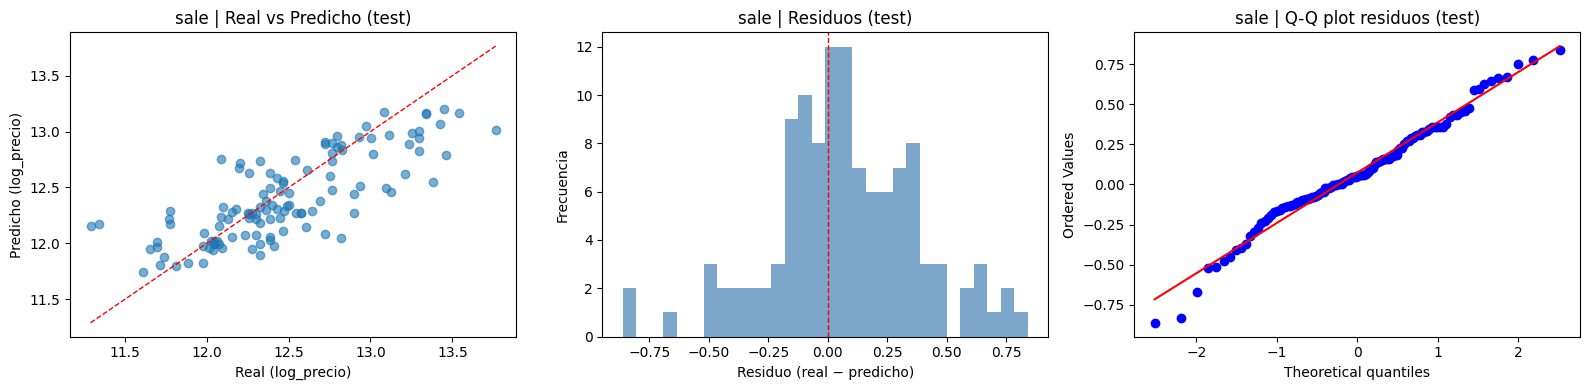


DATASET: RENT

Filas originales: 477
Detectando outliers en el target:
  Rango válido de log_precio: [6.1079, 7.8074]
  Outliers eliminados: 26 de 477 (5.5%)
  log_precio eliminados: [8.23  7.955 8.161 8.161 8.102 7.99  7.937 7.937 8.102 8.071 7.824 8.243
 7.824 8.071 8.202 7.882 7.901 7.972 8.102 8.216 7.937 7.882 8.006 8.161
 8.006 7.824]
  Precio equivalente (€): [3750 2850 3500 3500 3300 2950 2800 2800 3300 3200 2500 3800 2500 3200
 3650 2650 2700 2900 3300 3700 2800 2650 3000 3500 3000 2500]
Filas tras limpieza: 451
Features: 11 | Ausentes de BASE_FEATURES: []
Train: 360 filas | Test: 91 filas

Buscando mejores hiperparametros (50 combinaciones, CV=5 folds)...

Mejores hiperparametros encontrados:
  max_depth: 8
  max_features: 0.6
  max_samples: 0.7
  min_samples_leaf: 5
  min_samples_split: 15
  n_estimators: 500

Metricas (train / CV / test):
split     MSE    RMSE     MAE    MAPE      R2  R2_ajustado
train 0.03506 0.18725 0.14118 0.02026 0.61349      0.60127
   CV     NaN 0.23

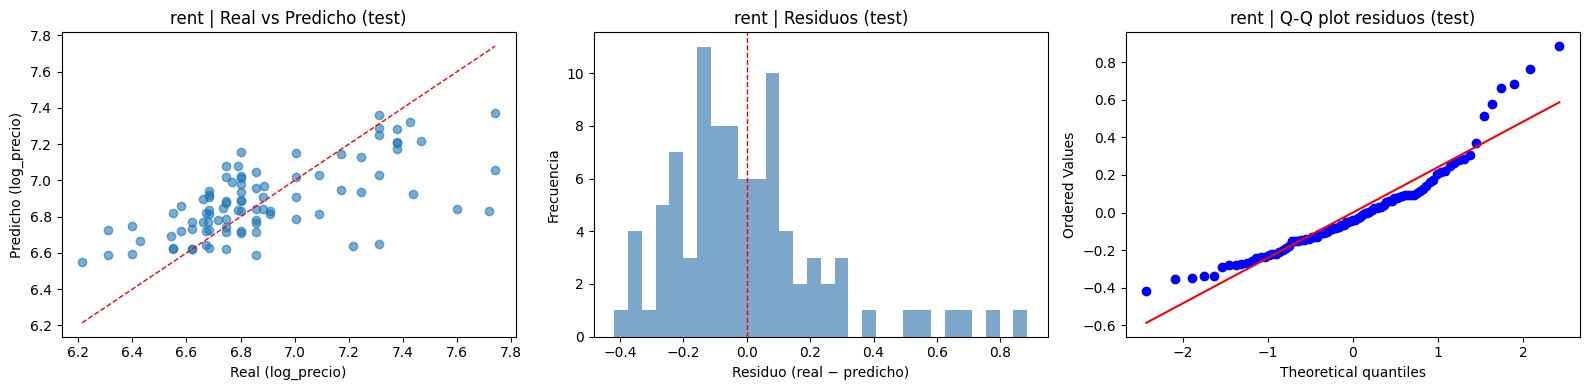


RESUMEN GLOBAL
dataset  n_filas_limpias  n_features_model  train_RMSE  cv_RMSE  test_RMSE  train_R2  test_R2  ratio_RMSE_test_train  delta_R2_train_test
   sale              582                11      0.2765   0.3445     0.3192    0.7467   0.5898                 1.1544               0.1569
   rent              451                11      0.1873   0.2313     0.2481    0.6135   0.4260                 1.3248               0.1875


,dataset,n_filas_limpias,n_features_model,train_RMSE,cv_RMSE,test_RMSE,train_R2,test_R2,ratio_RMSE_test_train,delta_R2_train_test
0,sale,582,11,0.276467,0.344545,0.319164,0.746745,0.589841,1.154438,0.156904
1,rent,451,11,0.187252,0.231318,0.248080,0.613488,0.426008,1.324845,0.187480


In [3]:
all_rows = []

for dataset_name, dataset_path in DATASETS.items():
    print()
    print("=" * 100)
    print(f"DATASET: {dataset_name.upper()}")

    # ── Carga de datos ────────────────────────────────────────────────────────
    df = pd.read_csv(dataset_path)
    if TARGET_COL not in df.columns:
        raise ValueError(f"No existe target '{TARGET_COL}' en {dataset_name}")
    df = df[df[TARGET_COL].notna()].copy()

    print(f"\nFilas originales: {len(df)}")

    # ── Eliminación de outliers ───────────────────────────────────────────────
    # Se hace ANTES del split para que ni train ni test tengan valores extremos.
    # Los outliers en el target distorsionan el aprendizaje y aumentan el error.
    print("Detectando outliers en el target:")
    df = remove_outliers(df)
    print(f"Filas tras limpieza: {len(df)}")

    # ── Construcción de features y split train/test ───────────────────────────
    features, missing = build_feature_list(df)
    X = df[features].copy()
    y = df[TARGET_COL].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )

    print(f"Features: {len(features)} | Ausentes de BASE_FEATURES: {missing}")
    print(f"Train: {len(X_train)} filas | Test: {len(X_test)} filas")

    # ── Entrenamiento con búsqueda de hiperparámetros ─────────────────────────
    print(f"\nBuscando mejores hiperparametros ({N_ITER_SEARCH} combinaciones, CV={N_SPLITS} folds)...")
    res = evaluate_rf(X_train, X_test, y_train, y_test)

    # ── Resultados ────────────────────────────────────────────────────────────
    print("\nMejores hiperparametros encontrados:")
    for param, val in sorted(res["best_params"].items()):
        print(f"  {param.replace('rf__', '')}: {val}")

    # Métricas en train, CV y test
    # CV RMSE: estimación más fiable de error en datos no vistos (media de 5 folds)
    detail = pd.DataFrame([
        {"split": "train", **res["train"]},
        {"split": "CV",    "MSE": None, "RMSE": res["cv_rmse"], "MAE": None, "MAPE": None, "R2": None, "R2_ajustado": None},
        {"split": "test",  **res["test"]},
    ])
    print("\nMetricas (train / CV / test):")
    print(detail.round(5).to_string(index=False))

    print(
        f"\nSobreajuste → ratio RMSE test/train: {res['overfit']['ratio_RMSE_test_train']:.4f}"
        f" | delta R2 train-test: {res['overfit']['delta_R2_train_test']:.4f}"
    )

    print("\nTop 15 importancias de features:")
    print(res["importances"].round(5).to_string(index=False))

    # ── Gráficos diagnósticos ─────────────────────────────────────────────────
    residuals = y_test - res["pred_test"]

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Gráfico 1: Real vs Predicho
    # La línea roja es la predicción perfecta; los puntos deben estar cerca de ella
    ax = axes[0]
    ax.scatter(y_test, res["pred_test"], alpha=0.6)
    lim = [min(y_test.min(), res["pred_test"].min()), max(y_test.max(), res["pred_test"].max())]
    ax.plot(lim, lim, "r--", linewidth=1)
    ax.set_title(f"{dataset_name} | Real vs Predicho (test)")
    ax.set_xlabel("Real (log_precio)")
    ax.set_ylabel("Predicho (log_precio)")

    # Gráfico 2: Histograma de residuos
    # Idealmente centrado en 0 y con forma de campana (distribución normal)
    ax = axes[1]
    ax.hist(residuals, bins=30, alpha=0.7, color="steelblue")
    ax.axvline(0, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"{dataset_name} | Residuos (test)")
    ax.set_xlabel("Residuo (real − predicho)")
    ax.set_ylabel("Frecuencia")

    # Gráfico 3: Q-Q plot
    # Si los puntos siguen la línea roja, los residuos son aproximadamente normales.
    # Las colas que se desvían indican outliers o distribución asimétrica.
    ax = axes[2]
    stats.probplot(residuals, dist="norm", plot=ax)
    ax.set_title(f"{dataset_name} | Q-Q plot residuos (test)")
    ax.get_lines()[1].set_color("red")   # Línea de referencia en rojo

    plt.tight_layout()
    plt.show()

    # ── Acumulación para el resumen final ─────────────────────────────────────
    all_rows.append({
        "dataset":               dataset_name,
        "n_filas_limpias":       len(df),
        "n_features_model":      res["p_features"],
        "train_RMSE":            res["train"]["RMSE"],
        "cv_RMSE":               res["cv_rmse"],
        "test_RMSE":             res["test"]["RMSE"],
        "train_R2":              res["train"]["R2"],
        "test_R2":               res["test"]["R2"],
        "ratio_RMSE_test_train": res["overfit"]["ratio_RMSE_test_train"],
        "delta_R2_train_test":   res["overfit"]["delta_R2_train_test"],
    })

# ── Resumen global ────────────────────────────────────────────────────────────
summary = pd.DataFrame(all_rows).reset_index(drop=True)
print()
print("=" * 100)
print("RESUMEN GLOBAL")
print(summary.round(4).to_string(index=False))
summary
